Prophet Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from helper_functions import (
    is_christmas,
    is_mothers_day,
    is_special_day,
    mothers_day,
    is_silvester,
    holiday_average_last_3_years
)


Prophet Model without Cross-Validation

Zielvariable: Tagesumsatz Restaurant
Regressoren : ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)']
Train length (vor Feiertag-Filter): 1475
Test length                       : 306
Train length (ohne Weihnachten/Silvester/Muttertag): 1463


07:38:43 - cmdstanpy - INFO - Chain [1] start processing
07:38:44 - cmdstanpy - INFO - Chain [1] done processing



--- METRIKEN (Prophet mit Features + Feiertags-Adjust) ---
MSE          : 8465863.36
RMSE         : 2909.62
R²           : 0.7740
MAE          : 2268.41
Relative MSE : 0.2699
MAPE         : 19.51%

Weihnachten im Testset (24.12.):


,Datum,Ist,Vorhersage



Silvester im Testset (31.12.):


,Datum,Ist,Vorhersage



Muttertag im Testset:


,Datum,Ist,Vorhersage
1591,2025-05-11,40176.1,29589.666667


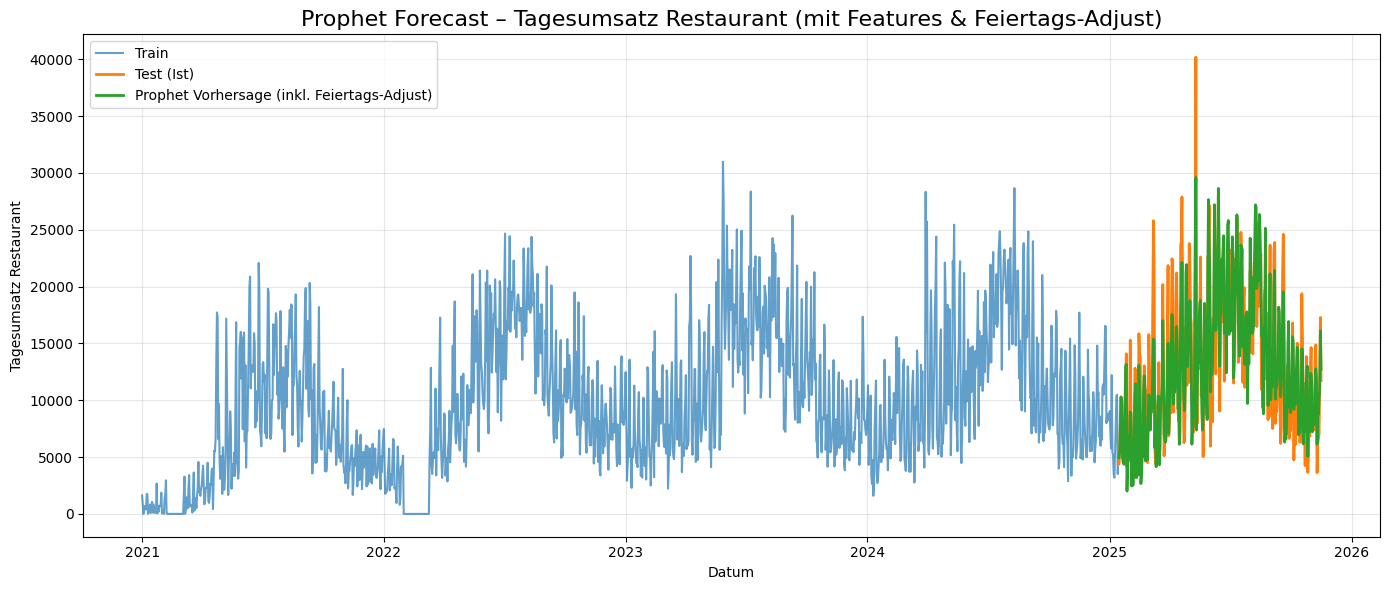

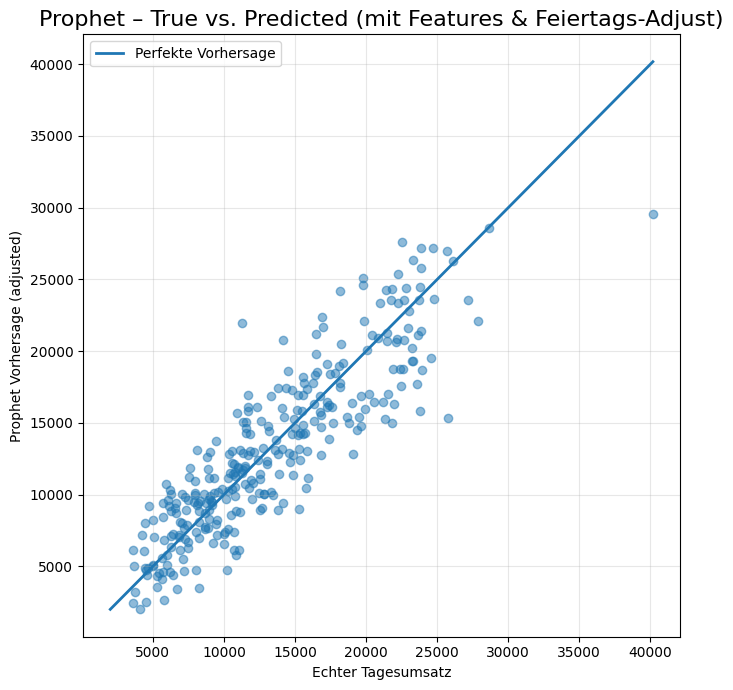

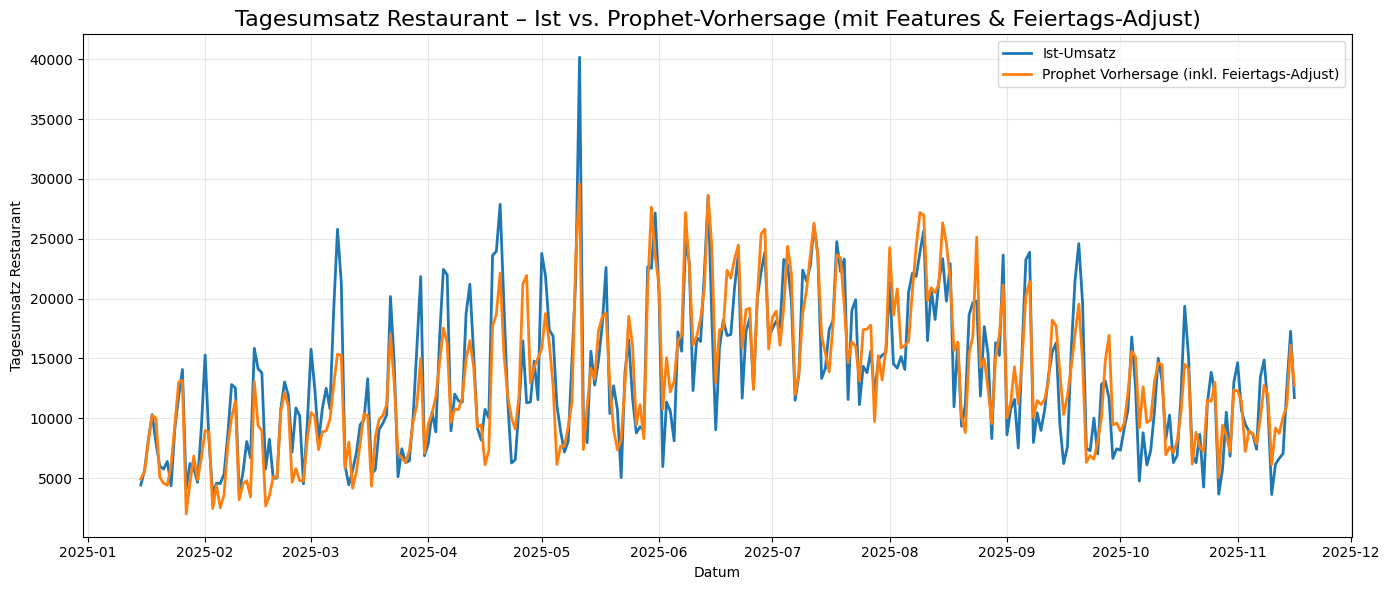

In [2]:
# ============================================
# 1) Daten laden und kleine Anpassungen machen
# ============================================
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Kopie mit Datum-Spalte für Feiertags-Helper
df_full = df.copy()

# Spalten entfernen, die Umsatzbestandteile sind um Data Leakage zu vermeiden
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Target variable definieren
target_col = "Tagesumsatz Restaurant"

# ============================================
# 2) Zeitreihe mit allen Features vorbereiten
#    tägliche Frequenz + Lücken füllen
# ============================================
df = df.set_index("Datum").asfreq("D")

#Sicherheitshalber forward und backward fill eingebaut
#Bräuchte es eigentlich nicht, weil Dataset bereits clean ist
df = df.ffill().bfill() 

# alle numerischen Spalten (unsere features)
num_cols = df.select_dtypes(include=["number"]).columns

# Ziel (target varaible) + Regressoren (Feature)
regressors = [c for c in num_cols if c != target_col]

print("Zielvariable:", target_col)
print("Regressoren :", regressors)

# Prophet-DataFrame: ds, y, plus alle Regressoren
df_p = df.reset_index().rename(columns={"Datum": "ds", target_col: "y"})


# ============================================
# 3a) Train/Test-Split (zeitbasiert)
# ============================================
split_date = pd.Timestamp("2025-01-15")
train = df_p[df_p["ds"] < split_date].copy()
test  = df_p[df_p["ds"] >= split_date].copy()

print("Train length (vor Feiertag-Filter):", len(train))
print("Test length                       :", len(test))

# ============================================
# 3b) Weihnachten, Silvester & Muttertag aus TRAINING entfernen
# ============================================
special_mask_train = train["ds"].apply(is_special_day)
train = train[~special_mask_train].copy()

print("Train length (ohne Weihnachten/Silvester/Muttertag):", len(train))

# ============================================
# 4) Prophet-Modell definieren und Regressoren hinzufügen
# ============================================
m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.16,   # Standard 0.05 → wir wollen mehr Trendflexibilität
)

#um die Vorhersage für das Frühjahr zu verbessern, extra Saisonalität einbauen
m.add_seasonality(name='yearly_extra', period=365.25, fourier_order=16)

# alle numerischen Zusatzfeatures als Regressoren
for reg in regressors:
    m.add_regressor(reg)

# ============================================
# 5) Modell fitten (train enthält y + alle Regressoren (features))
# ============================================
m.fit(train[["ds", "y"] + regressors])

# Prophet schätzt jetzt den Trend,
# wöchentliche und jährliche Saisonalität und 
# die Effekte der Regressoren

# ============================================
# 6) Zukunfts-DataFrame erzeugen (Train + Test Zeitraum)
# ============================================
future = m.make_future_dataframe(
    periods=len(test),
    freq="D"
)

# future mit Regressoren befüllen (aus df_p)
future = future.merge(
    df_p[["ds"] + regressors],
    on="ds",
    how="left"
)

forecast_all = m.predict(future)

# Nur die Testperiode herausholen und auf dieselben ds wie im Test setzen
forecast_test = forecast_all[forecast_all["ds"] >= split_date].copy()
forecast_test = forecast_test.set_index("ds").loc[test["ds"]].reset_index()

# ============================================
# 7) Vorhersagen + Feiertags-Adjust
# ============================================
y_true = test["y"].values
y_pred = forecast_test["yhat"].values

# Kopie für angepasste Vorhersage
y_pred_adjusted = y_pred.copy()
test_dates = forecast_test["ds"].values  # entspricht test["ds"]

for i, d in enumerate(test_dates):
    d = pd.Timestamp(d)
    year = d.year

    # Weihnachten (24.12.)
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 24),
            year=year,
            target_col=target_col
        )
        if avg_xmas is not None:
            y_pred_adjusted[i] = avg_xmas

    # Silvester (31.12.)
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full=df_full,
            date_func=lambda y_: pd.Timestamp(y_, 12, 31),
            year=year,
            target_col=target_col
        )
        if avg_silvester is not None:
            y_pred_adjusted[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full=df_full,
            date_func=mothers_day,
            year=year,
            target_col=target_col
        )
        if avg_mothers is not None:
            y_pred_adjusted[i] = avg_mothers

# ============================================
# 8) Metriken (mit Feiertags-Adjust)
# ============================================
mse  = mean_squared_error(y_true, y_pred_adjusted)
rmse = mse ** 0.5
r2   = r2_score(y_true, y_pred_adjusted)
mae  = mean_absolute_error(y_true, y_pred_adjusted)

# Naive Baseline: Vortag als Prognose
full_series = df_p.set_index("ds")["y"]
test_series = full_series.loc[test["ds"]]
y_naive = test_series.shift(1).bfill().values

mse_naive = mean_squared_error(y_true, y_naive)
relative_MSE = mse / mse_naive  # hier kannst du auch mse mit mse_model/MSE_naive ersetzen

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_true, y_pred_adjusted)

print("\n--- METRIKEN (Prophet mit Features + Feiertags-Adjust) ---")
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# ============================================
# 9) Ergebnis-DataFrame
# ============================================
results_prophet = pd.DataFrame({
    "Datum": test["ds"],
    "Ist": y_true,
    "Vorhersage": y_pred_adjusted
})

# Am Schluss: explizit Weihnachten, Silvester & Muttertag anzeigen
print("\nWeihnachten im Testset (24.12.):")
display(results_prophet[
    (results_prophet["Datum"].dt.month == 12) &
    (results_prophet["Datum"].dt.day == 24)
])

print("\nSilvester im Testset (31.12.):")
display(results_prophet[
    (results_prophet["Datum"].dt.month == 12) &
    (results_prophet["Datum"].dt.day == 31)
])

print("\nMuttertag im Testset:")
results_mothers = results_prophet[
    results_prophet["Datum"].apply(lambda d: d == mothers_day(d.year))
]
display(results_mothers)

# ============================================
# 10) Zeitreihen-Plot: Train, Test, Prophet-Vorhersage (adjusted)
# ============================================
plt.figure(figsize=(14,6))
plt.plot(train["ds"], train["y"], label="Train", alpha=0.7)
plt.plot(test["ds"], test["y"], label="Test (Ist)", linewidth=2)
plt.plot(results_prophet["Datum"], results_prophet["Vorhersage"],
         label="Prophet Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)

plt.title("Prophet Forecast – Tagesumsatz Restaurant (mit Features & Feiertags-Adjust)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 11) Scatter-Plot: True vs. Predicted (adjusted)
# ============================================
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred_adjusted, alpha=0.5)

min_val = min(y_true.min(), y_pred_adjusted.min())
max_val = max(y_true.max(), y_pred_adjusted.max())
plt.plot([min_val, max_val], [min_val, max_val],
         linewidth=2, label="Perfekte Vorhersage")

plt.title("Prophet – True vs. Predicted (mit Features & Feiertags-Adjust)", fontsize=16)
plt.xlabel("Echter Tagesumsatz")
plt.ylabel("Prophet Vorhersage (adjusted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 12) Kompakter Test-Plot: Ist vs. Prophet-Vorhersage (adjusted)
# ============================================
plt.figure(figsize=(14,6))
plt.plot(results_prophet["Datum"], results_prophet["Ist"],
         label="Ist-Umsatz", linewidth=2)
plt.plot(results_prophet["Datum"], results_prophet["Vorhersage"],
         label="Prophet Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)

plt.title("Tagesumsatz Restaurant – Ist vs. Prophet-Vorhersage (mit Features & Feiertags-Adjust)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Veranschaulichung add_seasonality im Prophet Modell (siehe Punkt 4. im Code oben)

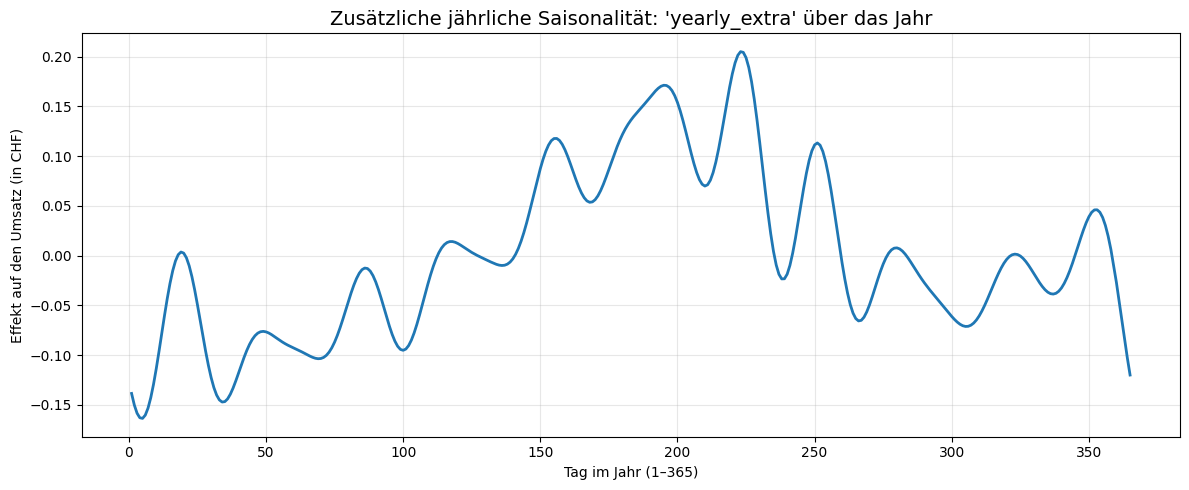

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Wir gehen davon aus, dass forecast_all bereits existiert
# und eine Spalte 'yearly_extra' enthält (so nennt Prophet deine Seasonality)

# 1) Nur ein Jahr betrachten, z.B. 2024
season = forecast_all.copy()
season["year"] = season["ds"].dt.year
season_2024 = season[season["year"] == 2024].copy()

# 2) Tag im Jahr berechnen (1–365)
season_2024["day_of_year"] = season_2024["ds"].dt.dayofyear

# 3) Plot der yearly_extra-Seasonality über das Jahr
plt.figure(figsize=(12, 5))
plt.plot(season_2024["day_of_year"], season_2024["yearly_extra"], linewidth=2)

plt.title("Zusätzliche jährliche Saisonalität: 'yearly_extra' über das Jahr", fontsize=14)
plt.xlabel("Tag im Jahr (1–365)")
plt.ylabel("Effekt auf den Umsatz (in CHF)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Prophet Model with Cross Validation

In [5]:
# ============================================
# 0) Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")


# ============================================
# Helper-Funktionen für Feiertage
# ============================================

def is_christmas(d):
    """Weihnachten (24.12.)"""
    d = pd.Timestamp(d)
    return (d.month == 12) and (d.day == 24)

def is_silvester(d):
    """Silvester (31.12.)"""
    d = pd.Timestamp(d)
    return (d.month == 12) and (d.day == 31)

def mothers_day(year):
    """
    Muttertag: 2. Sonntag im Mai (klassische CH/DE/AT-Regel).
    """
    may_first = pd.Timestamp(year, 5, 1)
    # Wochentag von 0=Montag ... 6=Sonntag
    weekday = may_first.weekday()
    # Tage bis zum ersten Sonntag
    days_to_sunday = (6 - weekday) % 7
    first_sunday = may_first + pd.Timedelta(days=days_to_sunday)
    # Muttertag = 2. Sonntag im Mai
    mothers_day_date = first_sunday + pd.Timedelta(days=7)
    return mothers_day_date

def is_mothers_day(d):
    """True, wenn Datum Muttertag des entsprechenden Jahres ist."""
    d = pd.Timestamp(d)
    return d == mothers_day(d.year)

def is_special_day(d):
    """Kombinierte Helper-Funktion für Weihnachten, Silvester & Muttertag."""
    d = pd.Timestamp(d)
    return is_christmas(d) or is_silvester(d) or is_mothers_day(d)

def holiday_average_last_3_years(df_full, date_func, year, target_col):
    """
    Durchschnitt des Zielwertes (target_col) an diesem Feiertag
    über die letzten 3 verfügbaren Jahre (year-1, year-2, year-3).

    df_full: Original-DataFrame mit Datum-Spalte 'Datum'
    date_func: Funktion, die ein Jahr -> Datum des Feiertages liefert
    year: aktuelles Prognosejahr
    target_col: Zielspalte, z.B. 'Tagesumsatz Restaurant'
    """
    vals = []
    for y in [year - 1, year - 2, year - 3]:
        if y < df_full["Datum"].dt.year.min():
            # falls zu weit zurück
            continue
        try:
            day = date_func(y)
            day = pd.Timestamp(day)
            mask = df_full["Datum"] == day
            if mask.any():
                vals.append(df_full.loc[mask, target_col].iloc[0])
        except Exception:
            continue

    if len(vals) == 0:
        return None
    return np.mean(vals)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (in %)."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# ============================================
# 1) Daten laden und kleine Anpassungen machen
# ============================================
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Kopie mit Datum-Spalte für Feiertags-Helper
df_full = df.copy()

# Spalten entfernen, die Umsatzbestandteile sind um Data Leakage zu vermeiden
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Target variable definieren
target_col = "Tagesumsatz Restaurant"

# ============================================
# 2) Zeitreihe mit allen Features vorbereiten
#    tägliche Frequenz + Lücken füllen
# ============================================
df = df.set_index("Datum").asfreq("D")

# Sicherheitshalber forward und backward fill
df = df.ffill().bfill()

# alle numerischen Spalten (unsere Features)
num_cols = df.select_dtypes(include=["number"]).columns

# Ziel (target variable) + Regressoren (Features)
regressors = [c for c in num_cols if c != target_col]

print("Zielvariable:", target_col)
print("Regressoren :", regressors)

# Prophet-DataFrame: ds, y, plus alle Regressoren
df_p = df.reset_index().rename(columns={"Datum": "ds", target_col: "y"})


# ============================================
# 3) Fixer Holdout-Testsplit
#    ALLES DAVOR = Trainingsdaten (für CV & finales Modell)
# ============================================
split_date = pd.Timestamp("2025-01-15")

train_all = df_p[df_p["ds"] < split_date].copy()
test_holdout = df_p[df_p["ds"] >= split_date].copy()

print("Train_all length:", len(train_all))
print("Holdout-Test length:", len(test_holdout))


# ============================================
# 4) CROSS VALIDATION: Expanding Window für 7-Tage-Forecast
#    Nur auf train_all, Holdout bleibt unangetastet
# ============================================
horizon_days = 7      # 1 Woche Forecast
min_train_days = 365  # Mindestens 1 Jahr Training für ersten Split (anpassbar)

all_dates_train = train_all["ds"].sort_values().unique()

cv_results = []

start_index = min_train_days

while start_index + horizon_days <= len(all_dates_train):

    # TRAIN / TEST Datumssplit innerhalb von train_all
    train_end = all_dates_train[start_index - 1]
    test_start = all_dates_train[start_index]
    test_end = all_dates_train[start_index + horizon_days - 1]

    train_cv = train_all[(train_all["ds"] <= train_end)].copy()
    test_cv = train_all[(train_all["ds"] >= test_start) & (train_all["ds"] <= test_end)].copy()

    # Feiertage aus TRAIN entfernen
    special_mask_train_cv = train_cv["ds"].apply(is_special_day)
    train_cv = train_cv[~special_mask_train_cv].copy()

    # Prophet Modell für diesen Fold
    m_cv = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.16
    )
    m_cv.add_seasonality(name="yearly_extra", period=365.25, fourier_order=16)

    for reg in regressors:
        m_cv.add_regressor(reg)

    # Fit
    m_cv.fit(train_cv[["ds", "y"] + regressors])

    # Zukunft: genau horizon_days Tage
    future_cv = m_cv.make_future_dataframe(periods=horizon_days, freq="D")
    future_cv = future_cv.merge(
        df_p[["ds"] + regressors],
        on="ds",
        how="left"
    )

    forecast_cv = m_cv.predict(future_cv)
    forecast_test_cv = forecast_cv[forecast_cv["ds"].isin(test_cv["ds"])].copy()
    forecast_test_cv = forecast_test_cv.sort_values("ds")

    # Feiertags-Adjust pro Fold
    y_pred_adj = []
    for i, d in enumerate(forecast_test_cv["ds"]):
        d = pd.Timestamp(d)
        pred_value = forecast_test_cv.iloc[i]["yhat"]

        year = d.year

        # Weihnachten
        if is_christmas(d):
            avg = holiday_average_last_3_years(
                df_full, lambda y: pd.Timestamp(y, 12, 24), year, target_col
            )
            if avg is not None:
                pred_value = avg

        # Silvester
        if is_silvester(d):
            avg = holiday_average_last_3_years(
                df_full, lambda y: pd.Timestamp(y, 12, 31), year, target_col
            )
            if avg is not None:
                pred_value = avg

        # Muttertag
        if is_mothers_day(d):
            avg = holiday_average_last_3_years(
                df_full, mothers_day, year, target_col
            )
            if avg is not None:
                pred_value = avg

        y_pred_adj.append(pred_value)

    y_true_cv = test_cv["y"].values
    y_pred_adj = np.array(y_pred_adj)

    # Metriken pro Fold
    fold_mse  = mean_squared_error(y_true_cv, y_pred_adj)
    fold_rmse = fold_mse ** 0.5
    fold_mae  = mean_absolute_error(y_true_cv, y_pred_adj)
    fold_mape = mape(y_true_cv, y_pred_adj)

    cv_results.append({
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "MSE": fold_mse,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "MAPE": fold_mape
    })

    # Nächster CV-Split: Fenster um 7 Tage nach vorne schieben
    start_index += horizon_days

# Resultate als DataFrame
cv_df = pd.DataFrame(cv_results)
print("\n--- CROSS VALIDATION RESULTATE (Expanding Window, 7-Tage Forecast auf train_all) ---")
display(cv_df)

print("\nDurchschnitt über alle CV-Splits:")
print(cv_df.mean(numeric_only=True))


# ============================================
# 5) FINALES MODELL: Train auf train_all, Test nur auf Holdout
# ============================================

# Feiertage aus finalem Training entfernen
train_final = train_all.copy()
special_mask_train_final = train_final["ds"].apply(is_special_day)
train_final = train_final[~special_mask_train_final].copy()

# Prophet-Modell
m_final = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.16
)
m_final.add_seasonality(name='yearly_extra', period=365.25, fourier_order=16)

for reg in regressors:
    m_final.add_regressor(reg)

# Fit auf allen Trainingsdaten (ohne Feiertage)
m_final.fit(train_final[["ds", "y"] + regressors])

# Zukunft: Länge = Holdout-Test
future_final = m_final.make_future_dataframe(
    periods=len(test_holdout),
    freq="D"
)
future_final = future_final.merge(
    df_p[["ds"] + regressors],
    on="ds",
    how="left"
)

forecast_all_final = m_final.predict(future_final)
forecast_holdout = forecast_all_final[forecast_all_final["ds"].isin(test_holdout["ds"])].copy()
forecast_holdout = forecast_holdout.sort_values("ds")

# Vorhersage + Feiertags-Adjust im Holdout
y_true_holdout = test_holdout["y"].values
y_pred_holdout = forecast_holdout["yhat"].values.copy()

for i, d in enumerate(forecast_holdout["ds"]):
    d = pd.Timestamp(d)
    year = d.year

    # Weihnachten
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full,
            lambda y_: pd.Timestamp(y_, 12, 24),
            year,
            target_col
        )
        if avg_xmas is not None:
            y_pred_holdout[i] = avg_xmas

    # Silvester
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full,
            lambda y_: pd.Timestamp(y_, 12, 31),
            year,
            target_col
        )
        if avg_silvester is not None:
            y_pred_holdout[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full,
            mothers_day,
            year,
            target_col
        )
        if avg_mothers is not None:
            y_pred_holdout[i] = avg_mothers

# ============================================
# 6) Metriken (Holdout-Test mit Feiertags-Adjust)
# ============================================
mse_h  = mean_squared_error(y_true_holdout, y_pred_holdout)
rmse_h = mse_h ** 0.5
r2_h   = r2_score(y_true_holdout, y_pred_holdout)
mae_h  = mean_absolute_error(y_true_holdout, y_pred_holdout)
mape_h = mape(y_true_holdout, y_pred_holdout)

# Naive Baseline: Vortag als Prognose (nur auf Holdout)
full_series = df_p.set_index("ds")["y"]
holdout_series = full_series.loc[test_holdout["ds"]]
y_naive_holdout = holdout_series.shift(1).bfill().values

mse_naive_h = mean_squared_error(y_true_holdout, y_naive_holdout)
relative_MSE_h = mse_h / mse_naive_h

print("\n--- FINALE METRIKEN (Holdout-Test, Prophet mit Features + Feiertags-Adjust) ---")
print(f"MSE          : {mse_h:.2f}")
print(f"RMSE         : {rmse_h:.2f}")
print(f"R²           : {r2_h:.4f}")
print(f"MAE          : {mae_h:.2f}")
print(f"MAPE         : {mape_h:.2f}%")
print(f"Relative MSE : {relative_MSE_h:.4f}")


# ============================================
# 7) Ergebnis-DataFrame & Plots für Holdout
# ============================================
results_holdout = pd.DataFrame({
    "Datum": test_holdout["ds"],
    "Ist": y_true_holdout,
    "Vorhersage": y_pred_holdout
})

print("\nWeihnachten im Holdout (24.12.):")
display(results_holdout[
    (results_holdout["Datum"].dt.month == 12) &
    (results_holdout["Datum"].dt.day == 24)
])

print("\nSilvester im Holdout (31.12.):")
display(results_holdout[
    (results_holdout["Datum"].dt.month == 12) &
    (results_holdout["Datum"].dt.day == 31)
])

print("\nMuttertag im Holdout:")
results_mothers_holdout = results_holdout[
    results_holdout["Datum"].apply(lambda d: d == mothers_day(d.year))
]
display(results_mothers_holdout)

# Zeitreihen-Plot für Holdout
plt.figure(figsize=(14,6))
plt.plot(train_all["ds"], train_all["y"], label="Train_all", alpha=0.7)
plt.plot(results_holdout["Datum"], results_holdout["Ist"],
         label="Holdout Ist", linewidth=2)
plt.plot(results_holdout["Datum"], results_holdout["Vorhersage"],
         label="Holdout Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)

plt.title("Tagesumsatz Restaurant – Holdout-Test vs. Prophet-Vorhersage (mit Feiertags-Adjust)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


07:39:55 - cmdstanpy - INFO - Chain [1] start processing


Zielvariable: Tagesumsatz Restaurant
Regressoren : ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)']
Train_all length: 1475
Holdout-Test length: 306


07:39:55 - cmdstanpy - INFO - Chain [1] done processing


ValueError: Found input variables with inconsistent numbers of samples: [7, 6]

07:45:30 - cmdstanpy - INFO - Chain [1] start processing


Zielvariable: Tagesumsatz Restaurant
Regressoren : ['is_fr_sa', 'Ferien-Value', 'Special-Day-Value', 'Niederschlag Tagessumme 6 UTC', 'Sonnenscheindauer Tagessumme', 'Lufttemperatur 2m Tagesmittel', 'Durchschnittliche Anzahl Geburtstage (über 100 Jahre)']
Train_all Länge: 1475
Holdout-Test Länge: 306


07:45:30 - cmdstanpy - INFO - Chain [1] done processing
07:45:30 - cmdstanpy - INFO - Chain [1] start processing
07:45:31 - cmdstanpy - INFO - Chain [1] done processing
07:45:31 - cmdstanpy - INFO - Chain [1] start processing
07:45:31 - cmdstanpy - INFO - Chain [1] done processing
07:45:31 - cmdstanpy - INFO - Chain [1] start processing
07:45:31 - cmdstanpy - INFO - Chain [1] done processing
07:45:31 - cmdstanpy - INFO - Chain [1] start processing
07:45:32 - cmdstanpy - INFO - Chain [1] done processing
07:45:32 - cmdstanpy - INFO - Chain [1] start processing
07:45:32 - cmdstanpy - INFO - Chain [1] done processing
07:45:32 - cmdstanpy - INFO - Chain [1] start processing
07:45:32 - cmdstanpy - INFO - Chain [1] done processing
07:45:32 - cmdstanpy - INFO - Chain [1] start processing
07:45:33 - cmdstanpy - INFO - Chain [1] done processing
07:45:33 - cmdstanpy - INFO - Chain [1] start processing
07:45:33 - cmdstanpy - INFO - Chain [1] done processing
07:45:33 - cmdstanpy - INFO - Chain [1] 


--- CROSS VALIDATION RESULTATE (Expanding Window, 7-Tage-Forecast auf train_all) ---


,train_end,test_start,test_end,MSE,RMSE,MAE,MAPE
0,2021-12-31,2022-01-01,2022-01-07,8.832531e+05,939.815469,699.239991,21.182770
1,2022-01-07,2022-01-08,2022-01-14,1.782578e+06,1335.132235,1218.596434,33.267528
2,2022-01-14,2022-01-15,2022-01-21,2.067490e+06,1437.876846,1288.996416,47.484184
3,2022-01-21,2022-01-22,2022-01-28,4.394881e+06,2096.397127,1752.337850,49.521077
4,2022-01-28,2022-01-29,2022-02-04,2.335298e+06,1528.168232,1387.717258,16.183200
...,...,...,...,...,...,...,...
153,2024-12-06,2024-12-07,2024-12-13,6.096735e+06,2469.156756,1743.310420,17.503205
154,2024-12-13,2024-12-14,2024-12-20,2.061261e+06,1435.709343,1266.454312,16.158661
155,2024-12-20,2024-12-21,2024-12-27,1.431218e+07,3783.143728,2917.977302,49.600021
156,2024-12-27,2024-12-28,2025-01-03,4.427711e+07,6654.104961,4551.741268,33.925576


...

,Datum,Ist,Vorhersage



Silvester im Holdout (31.12.):


,Datum,Ist,Vorhersage



Muttertag im Holdout:


,Datum,Ist,Vorhersage
1591,2025-05-11,40176.1,29589.666667


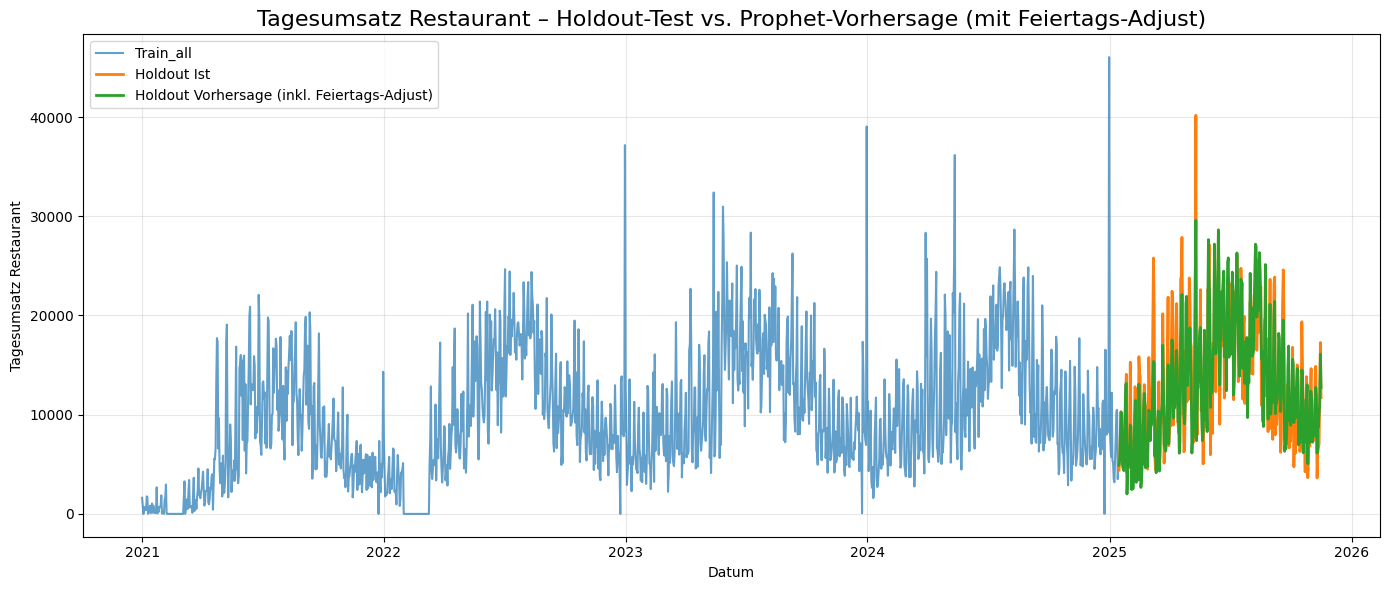

In [1]:
# ============================================
# 0) Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")


# ============================================
# Helper-Funktionen für Feiertage
# ============================================

def is_christmas(d):
    """Weihnachten (24.12.)"""
    d = pd.Timestamp(d)
    return (d.month == 12) and (d.day == 24)

def is_silvester(d):
    """Silvester (31.12.)"""
    d = pd.Timestamp(d)
    return (d.month == 12) and (d.day == 31)

def mothers_day(year):
    """
    Muttertag: 2. Sonntag im Mai (klassische CH/DE/AT-Regel).
    """
    may_first = pd.Timestamp(year, 5, 1)
    weekday = may_first.weekday()  # 0=Mo ... 6=So
    days_to_sunday = (6 - weekday) % 7
    first_sunday = may_first + pd.Timedelta(days=days_to_sunday)
    mothers_day_date = first_sunday + pd.Timedelta(days=7)
    return mothers_day_date

def is_mothers_day(d):
    d = pd.Timestamp(d)
    return d == mothers_day(d.year)

def is_special_day(d):
    """Weihnachten, Silvester oder Muttertag."""
    d = pd.Timestamp(d)
    return is_christmas(d) or is_silvester(d) or is_mothers_day(d)

def holiday_average_last_3_years(df_full, date_func, year, target_col):
    """
    Durchschnitt des Zielwertes (target_col) an diesem Feiertag
    über die letzten 3 Jahre (year-1, year-2, year-3).
    df_full: DataFrame mit 'Datum' und target_col
    date_func: year -> Feiertagsdatum
    """
    vals = []
    for y in [year - 1, year - 2, year - 3]:
        if y < df_full["Datum"].dt.year.min():
            continue
        try:
            day = pd.Timestamp(date_func(y))
            mask = df_full["Datum"] == day
            if mask.any():
                vals.append(df_full.loc[mask, target_col].iloc[0])
        except Exception:
            continue

    if len(vals) == 0:
        return None
    return np.mean(vals)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (in %)."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true != 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# ============================================
# 1) Daten laden und vorbereiten
# ============================================
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# Kopie mit Original-Datum für Feiertags-Helper / Holiday-Averages
df_full = df.copy()

# Spalten entfernen, die Umsatzbestandteile sind (Data Leakage vermeiden)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# Zielvariable
target_col = "Tagesumsatz Restaurant"

# ============================================
# 2) Zeitreihe auf tägliche Frequenz bringen
# ============================================
df = df.set_index("Datum").asfreq("D")
df = df.ffill().bfill()  # Sicherstellen, dass keine Lücken da sind

# Numerische Spalten = Features
num_cols = df.select_dtypes(include=["number"]).columns
regressors = [c for c in num_cols if c != target_col]

print("Zielvariable:", target_col)
print("Regressoren :", regressors)

# Prophet-DataFrame
df_p = df.reset_index().rename(columns={"Datum": "ds", target_col: "y"})


# ============================================
# 3) Fixer Holdout-Testsplit
#    ALLES DAVOR = Trainingsdaten (für CV & finales Modell)
# ============================================
split_date = pd.Timestamp("2025-01-15")

train_all = df_p[df_p["ds"] < split_date].copy()
test_holdout = df_p[df_p["ds"] >= split_date].copy()

print("Train_all Länge:", len(train_all))
print("Holdout-Test Länge:", len(test_holdout))


# ============================================
# 4) Expanding-Window Cross-Validation auf train_all
#    Ziel: 7-Tage-Forecast
# ============================================
horizon_days = 7      # 1 Woche
min_train_days = 365  # mindestens 1 Jahr Training für den ersten Fold (anpassbar)

all_dates_train = train_all["ds"].sort_values().unique()

cv_results = []

start_index = min_train_days

while start_index + horizon_days <= len(all_dates_train):

    # Datumssplit im Trainingsbereich
    train_end = all_dates_train[start_index - 1]
    test_start = all_dates_train[start_index]
    test_end = all_dates_train[start_index + horizon_days - 1]

    train_cv = train_all[train_all["ds"] <= train_end].copy()
    test_cv = train_all[(train_all["ds"] >= test_start) &
                        (train_all["ds"] <= test_end)].copy()

    # Sortieren zur Sicherheit
    train_cv = train_cv.sort_values("ds")
    test_cv = test_cv.sort_values("ds")

    # Feiertage aus TRAIN entfernen (aber NICHT aus Test)
    special_mask_train_cv = train_cv["ds"].apply(is_special_day)
    train_cv = train_cv[~special_mask_train_cv].copy()

    # Prophet-Modell für diesen Fold
    m_cv = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.16
    )
    m_cv.add_seasonality(name="yearly_extra", period=365.25, fourier_order=16)

    for reg in regressors:
        m_cv.add_regressor(reg)

    # Fit
    m_cv.fit(train_cv[["ds", "y"] + regressors])

    # 🔁 WICHTIG:
    # Zukunft NICHT mit make_future_dataframe,
    # sondern GENAU die Test-Daten dieses Folds
    future_cv = test_cv[["ds"]].merge(
        df_p[["ds"] + regressors],
        on="ds",
        how="left"
    )

    forecast_test_cv = m_cv.predict(future_cv)
    forecast_test_cv = forecast_test_cv.sort_values("ds")

    # Feiertags-Adjust in den Vorhersagen (Fold)
    y_pred_adj = []
    for i, d in enumerate(forecast_test_cv["ds"]):
        d = pd.Timestamp(d)
        pred_value = forecast_test_cv.iloc[i]["yhat"]
        year = d.year

        # Weihnachten
        if is_christmas(d):
            avg = holiday_average_last_3_years(
                df_full,
                lambda y: pd.Timestamp(y, 12, 24),
                year,
                target_col
            )
            if avg is not None:
                pred_value = avg

        # Silvester
        if is_silvester(d):
            avg = holiday_average_last_3_years(
                df_full,
                lambda y: pd.Timestamp(y, 12, 31),
                year,
                target_col
            )
            if avg is not None:
                pred_value = avg

        # Muttertag
        if is_mothers_day(d):
            avg = holiday_average_last_3_years(
                df_full,
                mothers_day,
                year,
                target_col
            )
            if avg is not None:
                pred_value = avg

        y_pred_adj.append(pred_value)

    y_true_cv = test_cv["y"].values
    y_pred_adj = np.array(y_pred_adj)

    # Metriken pro Fold
    fold_mse  = mean_squared_error(y_true_cv, y_pred_adj)
    fold_rmse = fold_mse ** 0.5
    fold_mae  = mean_absolute_error(y_true_cv, y_pred_adj)
    fold_mape = mape(y_true_cv, y_pred_adj)

    cv_results.append({
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "MSE": fold_mse,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "MAPE": fold_mape
    })

    # Nächster CV-Split: Fenster um 7 Tage nach vorne
    start_index += horizon_days

# CV-Resultate
cv_df = pd.DataFrame(cv_results)
print("\n--- CROSS VALIDATION RESULTATE (Expanding Window, 7-Tage-Forecast auf train_all) ---")
display(cv_df)

print("\nDurchschnitt über alle CV-Splits:")
print(cv_df.mean(numeric_only=True))


# ============================================
# 5) Finales Modell: Train auf train_all, Test nur auf Holdout
# ============================================

# Kopie der Trainingsdaten
train_final = train_all.copy()

# Feiertage aus finalem Training entfernen
special_mask_train_final = train_final["ds"].apply(is_special_day)
train_final = train_final[~special_mask_train_final].copy()

# Prophet-Modell
m_final = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.16
)
m_final.add_seasonality(name="yearly_extra", period=365.25, fourier_order=16)

for reg in regressors:
    m_final.add_regressor(reg)

# Fit auf allen Trainingsdaten (ohne Feiertage)
m_final.fit(train_final[["ds", "y"] + regressors])

# Zukunft: GENAU die Holdout-Tage
future_final = test_holdout[["ds"]].merge(
    df_p[["ds"] + regressors],
    on="ds",
    how="left"
)

forecast_holdout = m_final.predict(future_final)
forecast_holdout = forecast_holdout.sort_values("ds")

# Vorhersage + Feiertags-Adjust im Holdout
y_true_holdout = test_holdout["y"].values
y_pred_holdout = forecast_holdout["yhat"].values.copy()

for i, d in enumerate(forecast_holdout["ds"]):
    d = pd.Timestamp(d)
    year = d.year

    # Weihnachten
    if is_christmas(d):
        avg_xmas = holiday_average_last_3_years(
            df_full,
            lambda y_: pd.Timestamp(y_, 12, 24),
            year,
            target_col
        )
        if avg_xmas is not None:
            y_pred_holdout[i] = avg_xmas

    # Silvester
    if is_silvester(d):
        avg_silvester = holiday_average_last_3_years(
            df_full,
            lambda y_: pd.Timestamp(y_, 12, 31),
            year,
            target_col
        )
        if avg_silvester is not None:
            y_pred_holdout[i] = avg_silvester

    # Muttertag
    if is_mothers_day(d):
        avg_mothers = holiday_average_last_3_years(
            df_full,
            mothers_day,
            year,
            target_col
        )
        if avg_mothers is not None:
            y_pred_holdout[i] = avg_mothers


# ============================================
# 6) Metriken auf dem Holdout-Test
# ============================================
mse_h  = mean_squared_error(y_true_holdout, y_pred_holdout)
rmse_h = mse_h ** 0.5
r2_h   = r2_score(y_true_holdout, y_pred_holdout)
mae_h  = mean_absolute_error(y_true_holdout, y_pred_holdout)
mape_h = mape(y_true_holdout, y_pred_holdout)

# Naive Baseline (Vortag) nur auf Holdout
full_series = df_p.set_index("ds")["y"]
holdout_series = full_series.loc[test_holdout["ds"]]
y_naive_holdout = holdout_series.shift(1).bfill().values

mse_naive_h = mean_squared_error(y_true_holdout, y_naive_holdout)
relative_MSE_h = mse_h / mse_naive_h

print("\n--- FINALE METRIKEN (Holdout-Test, Prophet + Features + Feiertags-Adjust) ---")
print(f"MSE          : {mse_h:.2f}")
print(f"RMSE         : {rmse_h:.2f}")
print(f"R²           : {r2_h:.4f}")
print(f"MAE          : {mae_h:.2f}")
print(f"MAPE         : {mape_h:.2f}%")
print(f"Relative MSE : {relative_MSE_h:.4f}")


# ============================================
# 7) Ergebnis-DataFrame & Plots für Holdout
# ============================================
results_holdout = pd.DataFrame({
    "Datum": test_holdout["ds"],
    "Ist": y_true_holdout,
    "Vorhersage": y_pred_holdout
})

print("\nWeihnachten im Holdout (24.12.):")
display(results_holdout[
    (results_holdout["Datum"].dt.month == 12) &
    (results_holdout["Datum"].dt.day == 24)
])

print("\nSilvester im Holdout (31.12.):")
display(results_holdout[
    (results_holdout["Datum"].dt.month == 12) &
    (results_holdout["Datum"].dt.day == 31)
])

print("\nMuttertag im Holdout:")
results_mothers_holdout = results_holdout[
    results_holdout["Datum"].apply(lambda d: d == mothers_day(d.year))
]
display(results_mothers_holdout)

# Zeitreihen-Plot für Holdout
plt.figure(figsize=(14,6))
plt.plot(train_all["ds"], train_all["y"], label="Train_all", alpha=0.7)
plt.plot(results_holdout["Datum"], results_holdout["Ist"],
         label="Holdout Ist", linewidth=2)
plt.plot(results_holdout["Datum"], results_holdout["Vorhersage"],
         label="Holdout Vorhersage (inkl. Feiertags-Adjust)", linewidth=2)

plt.title("Tagesumsatz Restaurant – Holdout-Test vs. Prophet-Vorhersage (mit Feiertags-Adjust)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
